In [80]:
import numpy as np
import matplotlib.pyplot as plt
from material_models import *

def setTrialStateBWBNwD(TState, CState, PlasticHingePar):
    # Bouc-Wen Baber with Degradation and Pinching

	m = 1.0
	Fy = PlasticHingePar['Fy']
	xu = PlasticHingePar['xu']

	alpha = PlasticHingePar['alpha']
	ko = PlasticHingePar['ko']
	n = PlasticHingePar['n']
	eta = PlasticHingePar['eta']
	beta = PlasticHingePar['beta']

	rhoeps = PlasticHingePar['rhoeps']
	rhox = PlasticHingePar['rhox']
	phi = PlasticHingePar['phi']
	deltak = PlasticHingePar['deltak']
	deltaf = PlasticHingePar['deltaf']

	sigma = PlasticHingePar['sigma']
	u = PlasticHingePar['u']
	epsp = PlasticHingePar['epsp']
	rhop = PlasticHingePar['rhop']

	tolerance = 0.00001  # PlasticHingePar.tolerance
	maxNumIter = 1000    # PlasticHingePar.maxNumIter

	xmax  = PlasticHingePar["xmax"]
	xmaxp = PlasticHingePar["xmaxp"]

    # Load State Variables
	strain  = TState["strain"]
	Cstrain = CState["strain"]  # C
	Ce      = CState["e"]
	Cz      = CState["z"]

	# Set trial strain and compute strain increment
	Tstrain = strain
	dStrain = Tstrain - Cstrain

	count = 0
	startPoint = 0.01
	Tz = startPoint
	Tzold = startPoint
	Tznew = 1.0

	while ((np.abs(Tzold-Tznew) > tolerance) and count < maxNumIter):
		# Evaluate function f

		gp = np.exp((-0.5)*(Cstrain/sigma)**u)
		feps = 1.0 - np.exp((-0.5)*(Ce/epsp)**8)
		kp = ko*(1.0 - feps*gp*rhop)
		Te = Ce + (1.0-alpha)*kp/m*dStrain*Tz

		if ((np.abs(Tstrain)) >= (np.abs(xmaxp))):
			xmax = np.abs(Tstrain)
		else:
			xmax = xmaxp
		xmaxp = xmax

		TDamIndex = rhoeps*Te*m/(Fy*xu) + rhox*np.abs(xmax)/xu
		Tpk = np.exp(-phi*TDamIndex)
		TA = np.exp(-deltak*TDamIndex*Tpk)
		Tbetak = beta*TA
		Tbetaf = np.exp(n*deltaf*TDamIndex)
		Psi = (eta + np.sign(dStrain*Tz))
		TPow = (np.abs(Tz)**(n))
		Phi = TA - TPow*Tbetak*Tbetaf*Psi
		f = Tz - Cz - Phi*dStrain

		# Evaluate function derivative f_z ( _z = derivative with respect to z_n+1 )

		Te_z = (1.0-alpha)*kp*dStrain/m
		TDamIndex_z = rhoeps*Te_z*m/(Fy*xu)
		Tpk_z = Tpk*(-phi*TDamIndex_z)
		TA_z = TA*(-deltak*TDamIndex_z*Tpk - deltak*TDamIndex*Tpk_z)
		Tbetak_z = beta*TA_z
		Tbetaf_z = Tbetaf*(n*deltaf*TDamIndex_z)

		if (Tz == 0.0):
			TPow = 0.0
			TPow_z = 0.0
		else:
			TPow = (np.abs(Tz))**(n)
			TPow_z = n*((np.abs(Tz))**(n-1))*np.sign(Tz)

		Phi_z = TA_z - (TPow_z*Tbetak*Tbetaf + TPow*Tbetak_z*Tbetaf + TPow*Tbetak*Tbetaf_z)*Psi
		f_z = 1.0 - Phi_z*dStrain

		# Issue warning if derivative is zero
		if (np.abs(f_z)<1.0e-10):
			print("WARNING: DegradingPinchedBW::setTrialStrain() -- zero derivative in Newton-Raphson scheme")

		# Take a Newton step
		Tznew = Tz - f/f_z

		# Update the root (but the keep the old for convergence check)
		Tzold = Tz
		Tz = Tznew

		# Update counter
		count = count + 1

		# Issue warning if we didn't converge
		if (count == maxNumIter):
			print("WARNING: DegradingPinchedBW::setTrialStrain() -- did not find the root z_{i+1}")

		# Compute stress
		Tstress = alpha*kp*Tstrain + (1-alpha)*kp*Tz

		# Compute deterioration parameters

		Te = Ce + (1-alpha)*kp*dStrain*Tz/m
		TDamIndex = rhoeps*Te*m/(Fy*xu) + rhox*abs(xmax)/xu
		Tpk = np.exp(-phi*TDamIndex)
		TA = np.exp(-deltak*TDamIndex*Tpk)
		Tbetak = beta*TA
		Tbetaf = np.exp(n*deltaf*TDamIndex)

		if (Tz == 0.0):
			TPow = 0.0
			TPow_z = 0.0
		else:
			TPow = (abs(Tz)**(n))
			TPow_z = n*(abs(Tz)**(n-1))*np.sign(Tz)

		Psi = eta + np.sign(dStrain*Tz)
		Phi =  TA - TPow*Tbetak*Tbetaf*Psi

		# Compute tangent ( _x = derivative with respect to x_n+1 )

		# Compute the derivative of f with respect to x_n+1
		if (Tz != 0.0):

			Te_x = (1 - alpha)*kp*Tz/m

			if (xmax == Tstrain):
				TDamIndex_x = rhoeps*Te_x*m/(Fy*xu) + rhox/xu
			else:
				TDamIndex_x = rhoeps*Te_x*m/(Fy*xu)

			Tpk_x = Tpk*(-phi*TDamIndex_x)
			TA_x = TA*(-deltak*TDamIndex_x*Tpk - deltak*TDamIndex*Tpk_x)
			Tbetak_x = beta*TA_x
			Tbetaf_x = Tbetaf*(n*deltaf*TDamIndex_x)
			Phi_x = TA_x - (TPow*Tbetak_x*Tbetaf + TPow*Tbetak*Tbetaf_x)*Psi
			f_x = -Phi - Phi_x*dStrain

		    # Compute the derivative of f_z with respect to x_n+1
			Te_z_x = (1 - alpha)*kp/m
			TDamIndex_z_x = rhoeps*Te_z_x*m/(Fy*xu)
			Tpk_z_x = Tpk_x*(-phi*TDamIndex_z) + Tpk*(-phi*TDamIndex_z_x)
			TA_z_x = TA_x*(-deltak*TDamIndex_z*Tpk - deltak*TDamIndex*Tpk_z) - TA*(deltak*TDamIndex_z_x*Tpk + deltak*TDamIndex_z*Tpk_x + deltak*TDamIndex_x*Tpk_z + deltak*TDamIndex*Tpk_z_x)
			Tbetak_z_x = beta*TA_z_x
			Tbetaf_z_x = Tbetaf_x*(n*deltaf*TDamIndex_z) + Tbetaf*(n*deltaf*TDamIndex_z_x)
			Phi_z_x = TA_z_x - (TPow_z*Tbetak*Tbetaf_x + TPow_z*Tbetak_x*Tbetaf + TPow*Tbetaf_z_x*Tbetak + TPow*Tbetaf_z*Tbetak_x + TPow*Tbetaf_x*Tbetak_z + TPow*Tbetaf*Tbetak_z_x)*Psi
			f_z_x = -Phi_z - Phi_z_x*dStrain

		# Compute tangent
			DzDeps = -(f_x*f_z - f*f_z_x)/((f_z**2))
			Ttangent = alpha*kp + (1-alpha)*kp*DzDeps
			# Ttangent = Tstress/Tstrain
		else:
			Ttangent = alpha*ko + (1-alpha)*ko

	# Store data in Tstate
	TState["e"] = Te
	TState["tangent"] = Ttangent
	TState["stress"] = Tstress
	TState["z"] = Tz

	PlasticHingePar["xmax"]  = xmax
	PlasticHingePar["xmaxp"] = xmaxp

	return TState, CState, PlasticHingePar


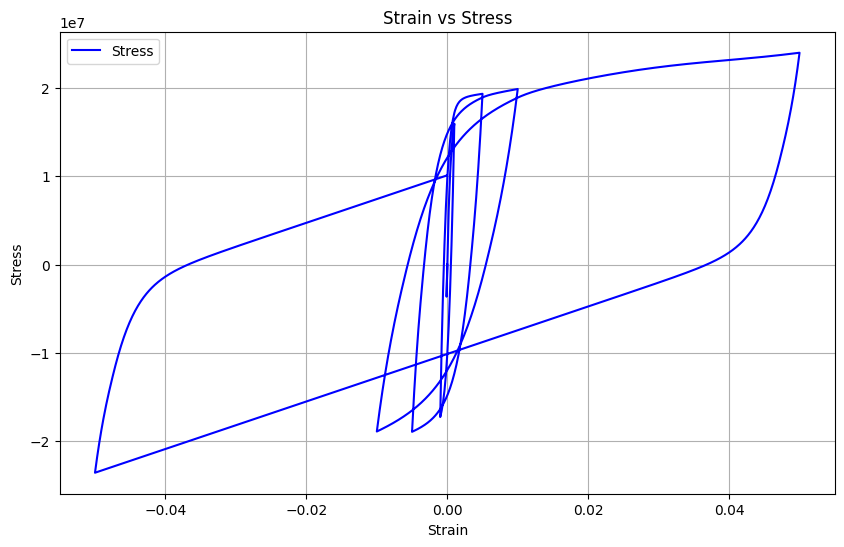

In [82]:
# Let's test the material model

NL = 1.0 # Nonlinear flag

PlasticHingePar = {
    "Fy": 38432000,
    "thetay": 0.001,
    "xu": 0.01,
    "alpha": 0.007,
    "ko": 38432000/0.001,
    "n": 1.28,
    "eta": 0.0,
    "beta": 17000/(1 + (1 - NL)*17000),
    "rhoeps": 0.0,
    "rhox": NL*0.25,
    "phi": 1.6,
    "deltak": NL*15.0,
    "deltaf": NL*0.50,
    "sigma": 0.01,
    "u": 4.0,
    "epsp": 0.001,
    "rhop": 0*0.1,
    "xmax": 0,
    "xmaxp": 0,
    "tolerance": 0.001,
    "maxNumIter": 1000
}

CState = {
    "strain": 0.0,
    "tangent": PlasticHingePar["ko"],
    "stress": 0.0,
    "e": 0.0,
    "z": 0.0
}

TState = {
    "strain": 0.0,
    "tangent": PlasticHingePar["ko"],
    "stress": 0.0,
    "e": 0.0,
    "z": 0.0
}

# Create a set of strains to test the material
time = np.linspace(0, 30, 10000)
#strain_values = 0.005*time/5*np.sin(2 * np.pi * time)
strain_values = createCyclicStrain(maxStrains=[0.0001, 0.001, 0.005, 0.01, 0.05], dStrain=0.0001)
strain_values = strain_values[0]

results = []
# Loop over the strain values, create a trial strain with the new strain value, and then use the current state to update the trial state
for strain in strain_values:
    TState["strain"] = strain
    TState, CState, PlasticHingePar = setTrialStateBWBNwD(TState, CState, PlasticHingePar)
    # Commit the state
    CState = TState.copy()
    # Record the results
    results.append({
        "strain": CState["strain"],
        "stress": CState["stress"],
        "tangent": CState["tangent"],
        "e": CState["e"],
    })

# Plot the strain vs stress
strain_values = [result["strain"] for result in results]
stress_values = [result["stress"] for result in results]

plt.figure(figsize=(10, 6))
plt.plot(strain_values, stress_values, label="Stress", color="blue")
plt.xlabel("Strain")
plt.ylabel("Stress")
plt.title("Strain vs Stress")
plt.legend()
plt.grid()
plt.show()